<a href="https://colab.research.google.com/github/Suhrobjonibodullayev/Mini-projects/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold,KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error
)

In [ ]:
url = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"

import pandas as pd

df = pd.read_csv(url, index_col=0)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info() # umumiy malumotlar ustunlar haqida

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null 

In [ ]:
df.dtypes.value_counts() # malumot turlarining taqsimoti

,count
object,17
int64,2
float64,1


In [ ]:
df.duplicated().sum() # duplicatlar soni

np.int64(22)

In [ ]:
df[df.duplicated(keep=False)].head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
1066-JKSGK,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
6380-ARCEH,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.2,No
2866-IKBTM,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
0887-HJGAR,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.7,Yes
3030-ZKIWL,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No


In [ ]:
df.drop_duplicates(inplace=True) # duplicatlarni olib tashlash

In [ ]:
print("Dataset:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Duplicate %:", round(df.duplicated().mean() * 100, 2))

Dataset: (7021, 20)
Duplicates: 0
Duplicate %: 0.0


In [ ]:
mask = df["TotalCharges"] == " "
df.loc[mask, "TotalCharges"]= np.nan
df = df.dropna(subset=["TotalCharges"])

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(8)

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [ ]:
df.MultipleLines.value_counts()

,count
MultipleLines,
No,3363
Yes,2967
No phone service,680


In [ ]:
#label encoding

binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in binary_cols:
  df[col] = LabelEncoder().fit_transform(df[col])


In [ ]:
cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

for col in cols:
  df[col] = df[col].replace({"No":0, "Yes":1, "No phone service":0, "No internet service":0})


/tmp/ipykernel_1502/2180623489.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({"No":0, "Yes":1, "No phone service":0, "No internet service":0})


In [ ]:
multi_cols = ["Contract", "InternetService","PaymentMethod"]

df= pd.get_dummies(df, columns= multi_cols)

In [ ]:
df.dtypes.value_counts() # malumot turlarining taqsimoti

,count
int64,15
bool,10
float64,1
object,1


In [ ]:
num_cols = ["tenure","MonthlyCharges","TotalCharges"]

In [ ]:
df = df.reset_index()
df.drop("customerID",axis=1, inplace=True) # customer id ustunini tashlab yuboramiz

In [ ]:
df.Churn.value_counts(normalize=True) # targetni qanday balansda ekanini foizda ko'rish

,proportion
Churn,
0,0.735093
1,0.264907


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# train/ test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# scaling
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

model.score(X_train, y_train),model.score(X_test, y_test)

(0.8040299572039943, 0.8074179743223966)

Accuracy: 0.8074179743223966
Precision: 0.6688963210702341
Recall: 0.5390835579514824
F1 Score: 0.5970149253731343
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



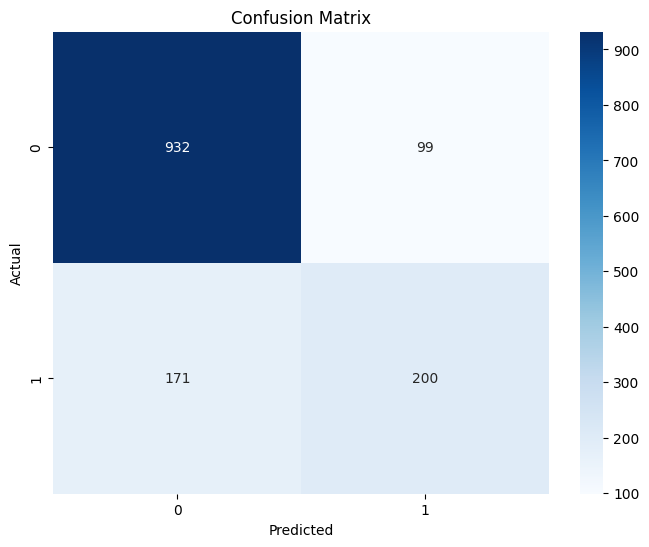

In [ ]:
def evaluate_model(y_test,pred):

    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))

    print(classification_report(y_test, pred))

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')


evaluate_model(y_test,pred)

Accuracy: 0.7860199714693296
Precision: 0.6802030456852792
Recall: 0.3611859838274933
F1 Score: 0.47183098591549294
              precision    recall  f1-score   support

           0       0.80      0.94      0.87      1031
           1       0.68      0.36      0.47       371

    accuracy                           0.79      1402
   macro avg       0.74      0.65      0.67      1402
weighted avg       0.77      0.79      0.76      1402



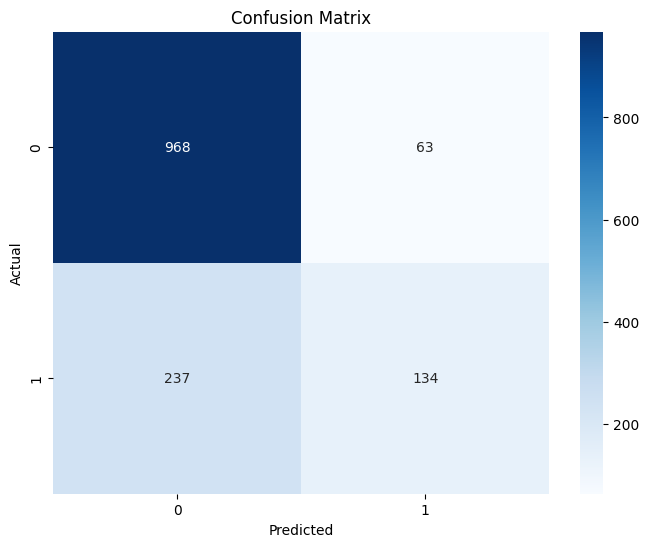

In [ ]:
# Decision Tree

Dt = DecisionTreeClassifier(max_depth=3, random_state=42)
Dt.fit(X_train, y_train)
pred = Dt.predict(X_test)

Dt.score(X_train, y_train),Dt.score(X_test, y_test)

evaluate_model(y_test,pred)

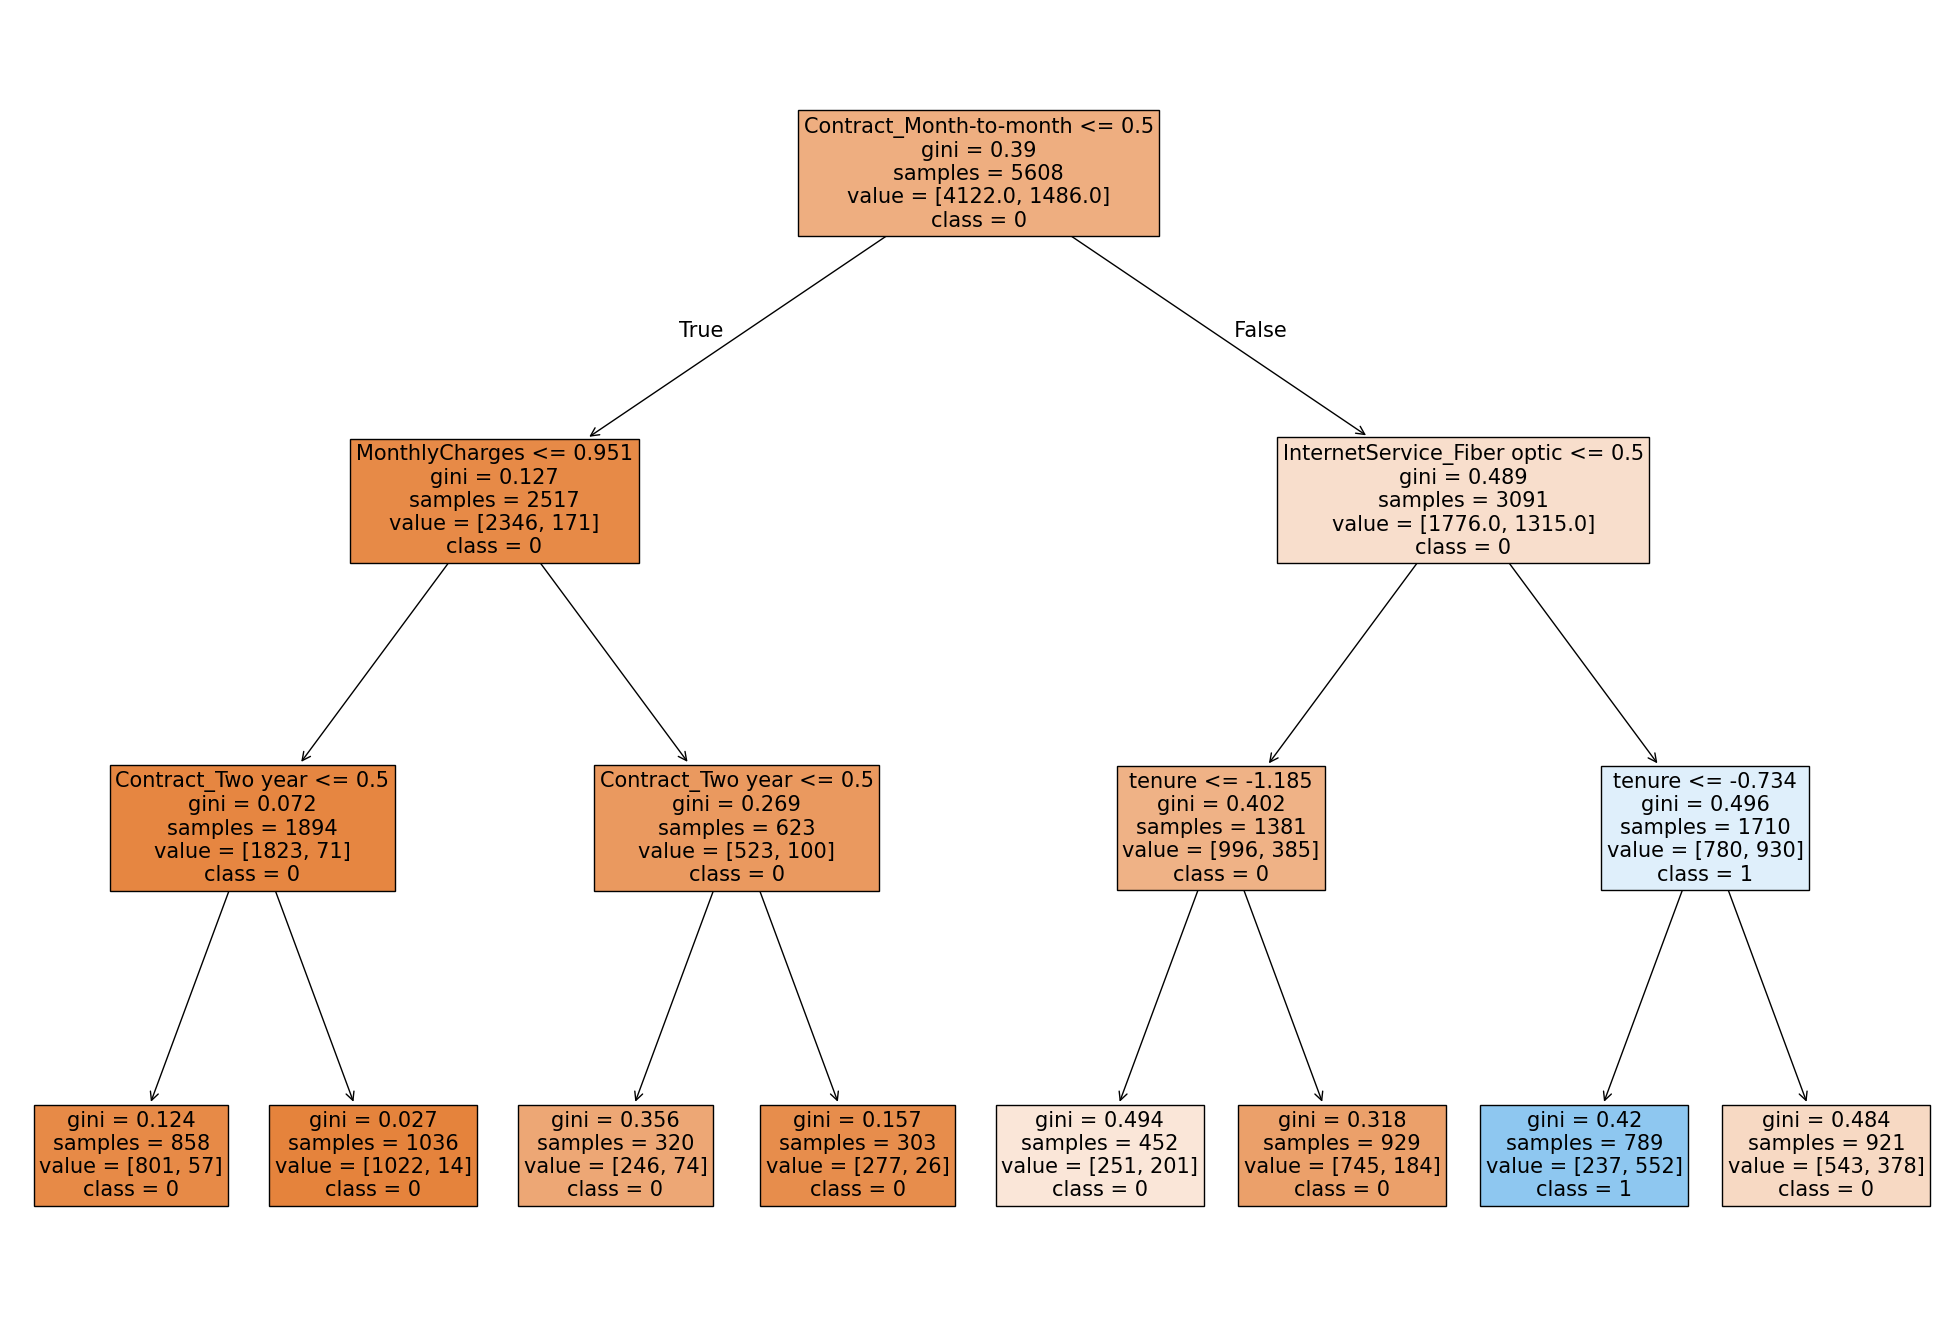

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 17))
plot_tree(Dt, filled=True, feature_names=X_train.columns, class_names=["0", "1"], fontsize = 15)
plt.show()

Accuracy: 0.760342368045649
Precision: 0.5487465181058496
Recall: 0.5309973045822103
F1 Score: 0.5397260273972603
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1031
           1       0.55      0.53      0.54       371

    accuracy                           0.76      1402
   macro avg       0.69      0.69      0.69      1402
weighted avg       0.76      0.76      0.76      1402



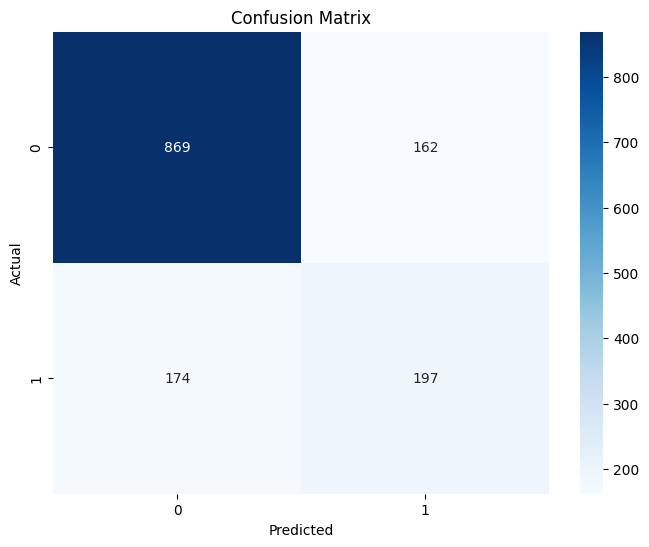

In [ ]:
# knn

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

knn.score(X_train, y_train),knn.score(X_test, y_test)

evaluate_model(y_test,pred)

Accuracy: 0.8074179743223966
Precision: 0.6666666666666666
Recall: 0.5444743935309974
F1 Score: 0.599406528189911
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



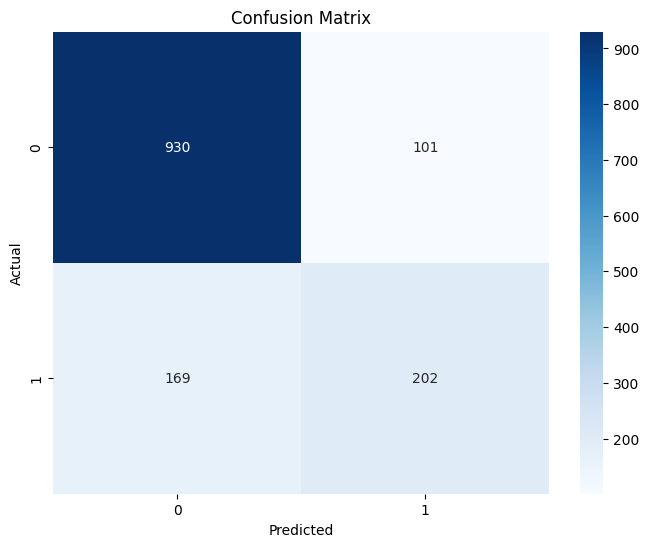

In [ ]:
# SVM
svm = SVC(kernel='linear',C=0.8, random_state=42)
svm.fit(X_train, y_train)
pred = svm.predict(X_test)

svm.score(X_train, y_train),svm.score(X_test, y_test)

evaluate_model(y_test,pred)


In [ ]:
# Random forest

Rf = RandomForestClassifier(n_estimators=90, max_depth=8, random_state=42)
Rf.fit(X_train, y_train)
pred = Rf.predict(X_test)

Rf.score(X_train, y_train),Rf.score(X_test, y_test)


(0.833808844507846, 0.8045649072753209)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {"max_depth": np.arange(1, 15),
          "max_features": ["sqrt", 0.5, None],
          "n_estimators": np.arange(10,100,10)}

from time import time
start = time()
gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                  params, scoring="accuracy")

gs.fit(X_train, y_train)
end = time()

print(round(end - start, 4))
print(gs.best_params_)
print(round(gs.best_score_, 4))
print(round(gs.best_estimator_.score(X_test, y_test), 4))

828.8829
{'max_depth': np.int64(8), 'max_features': 'sqrt', 'n_estimators': np.int64(90)}
0.8005
0.8046


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=42)

cross_val_score(model, X_train, y_train, cv=cv).mean()



np.float64(0.8017114525641575)